Menentukan Objek Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Menentukan Objek Data
df = pd.read_csv("/content/shopping_behavior_updated.csv")

print("Ukuran dataset:", df.shape)
display(df.head())
df.info()

Ukuran dataset: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

Membersihkan Data

In [59]:
# Tahap 2: Membersihkan data
# Menghapus duplikasi, menangani missing values jika ada
print("Jumlah duplikasi sebelum:", df.duplicated().sum())
df = df.drop_duplicates()

print("Jumlah missing value sebelum perbaikan:")
print(df.isna().sum())

# Mengisi missing values numerik dengan median & kategorikal dengan modus
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("\nJumlah missing value setelah perbaikan:")
print(df.isna().sum())

Jumlah duplikasi sebelum: 0
Jumlah missing value sebelum perbaikan:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Jumlah missing value setelah perbaikan:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount A

/tmp/ipython-input-2695815735.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2695815735.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Mengkontruksi Data

In [60]:
# Tahap 3: Mengonstruksi data (Encoding kategori → numerik)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Cari kolom numerik & kategorikal
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Pastikan kolom target tidak ikut di-encode
if "Review Rating" in categorical_cols:
    categorical_cols.remove("Review Rating")
if "Review Rating" in numeric_cols:
    numeric_cols.remove("Review Rating")

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
], remainder="passthrough")


Menentukan Label Data

In [61]:
# Tahap 4: Menentukan label data
# Konversi Review Rating menjadi kelas (Buruk / Netral / Baik)

def convert_rating_to_class(x):
    if x <= 2:
        return 0      # Buruk
    elif x == 3:
        return 1      # Netral
    else:
        return 2      # Baik

df["Rating_Class"] = df["Review Rating"].apply(convert_rating_to_class)

X = df.drop(columns=["Review Rating", "Rating_Class"])
y = df["Rating_Class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

print("Distribusi label:")
print(y.value_counts())


Distribusi label:
Rating_Class
2    3738
1     162
Name: count, dtype: int64


Membangun Model Data

In [63]:
# Tahap 5: Membangun model data
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Model berhasil dilatih menggunakan label Rating_Class.")


Model berhasil dilatih menggunakan label Rating_Class.


Mengevaluasi Hasil Pemodelan Data

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        32
           2       0.96      1.00      0.98       748

    accuracy                           0.96       780
   macro avg       0.48      0.50      0.49       780
weighted avg       0.92      0.96      0.94       780

Akurasi: 0.958974358974359


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


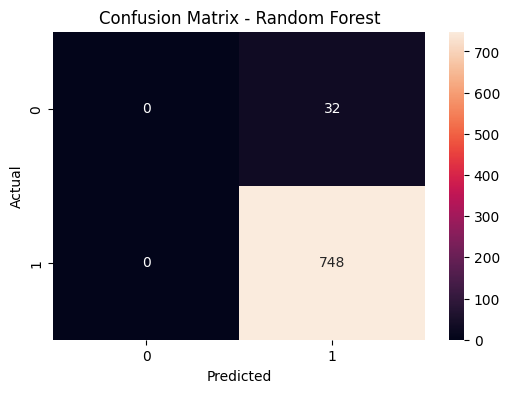

In [64]:
# Tahap 6: Evaluasi model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("Akurasi:", accuracy_score(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


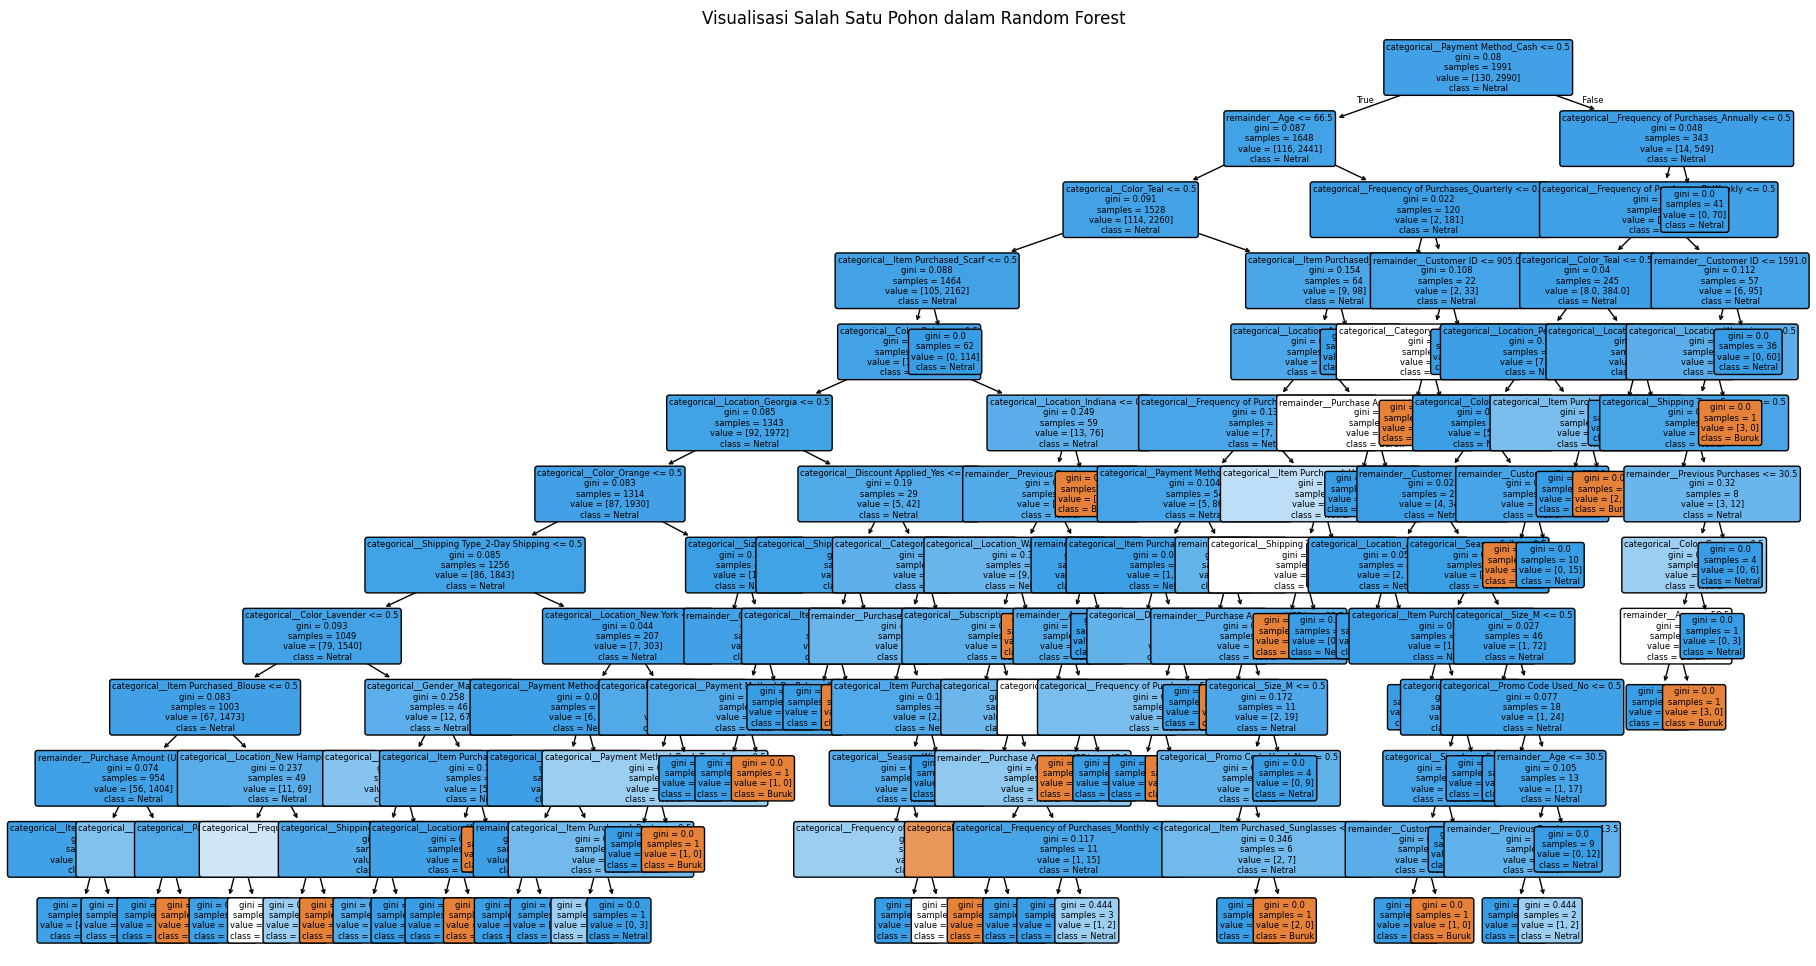

In [65]:
# Visualisasi Pohon Keputusan dari Model Random Forest
# Cell ini ditempatkan setelah pelatihan model selesai

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Ambil salah satu tree dari Random Forest (misal tree ke-0)
rf_tree = model.named_steps["rf"].estimators_[0]

plt.figure(figsize=(22, 12))  # ukuran besar agar terbaca
plot_tree(
    rf_tree,
    feature_names=model.named_steps["preprocess"].get_feature_names_out(),
    class_names=["Buruk", "Netral", "Baik"],   # label untuk Rating_Class
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title("Visualisasi Salah Satu Pohon dalam Random Forest")
plt.show()


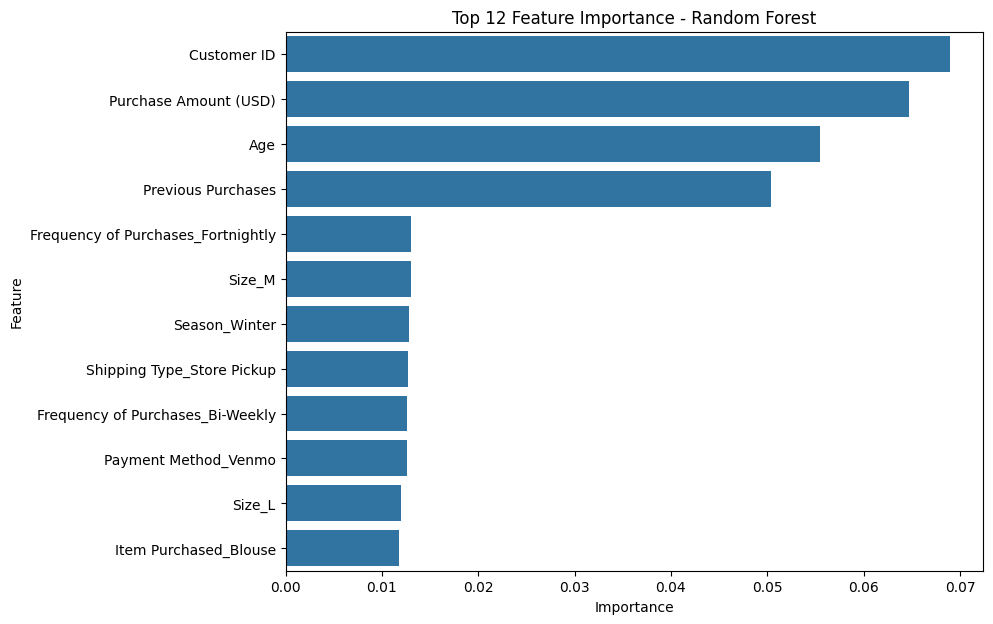

,Feature,Importance
139,Customer ID,0.068947
141,Purchase Amount (USD),0.064684
140,Age,0.055509
142,Previous Purchases,0.050431
135,Frequency of Purchases_Fortnightly,0.013009
82,Size_M,0.013002
113,Season_Winter,0.012845
121,Shipping Type_Store Pickup,0.012688
133,Frequency of Purchases_Bi-Weekly,0.012629
131,Payment Method_Venmo,0.012589


In [66]:
# Analisis kontribusi fitur (Feature Importance)
rf = model.named_steps["rf"]

# Ambil nama fitur setelah one-hot encoding
encoded_features = list(model.named_steps["preprocess"].transformers_[0][1].get_feature_names_out(categorical_cols))
all_features = encoded_features + numeric_cols

import pandas as pd
importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
sns.barplot(data=importance.head(12), x="Importance", y="Feature")
plt.title("Top 12 Feature Importance - Random Forest")
plt.show()

importance.head(12)
